In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fitz
import os
import langchain
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [2]:
pdf_path = 'C:/Users/adminn/LLM_Medical_chatbot/data/Medical_book.pdf'
loader = PyPDFLoader(pdf_path)

In [3]:
pdf_doc = loader.load()
print(f"Total Pages :", len(pdf_doc))

Total Pages : 637


In [ ]:
dataset_summary = []

for doc in pdf_doc:
    dataset_summary.append({
        "page": doc.metadata.get("page"),
        "source": doc.metadata.get("source"),
        "total_pages": doc.metadata.get("total_pages"),
        "producer": doc.metadata.get("producer"),
        "creator": doc.metadata.get("creator"),
        "characters": len(doc.page_content),
        "words": len(doc.page_content.split())
    })

pdf_summary = pd.DataFrame(dataset_summary)

pdf_summary.head()

,page,source,total_pages,producer,creator,characters,words
0,0,C:/Users/adminn/LLM_Medical_chatbot/data/Medic...,637,PDFlib+PDI 5.0.0 (SunOS),PyPDF,0,0
1,1,C:/Users/adminn/LLM_Medical_chatbot/data/Medic...,637,PDFlib+PDI 5.0.0 (SunOS),PyPDF,48,7
2,2,C:/Users/adminn/LLM_Medical_chatbot/data/Medic...,637,PDFlib+PDI 5.0.0 (SunOS),PyPDF,130,19
3,3,C:/Users/adminn/LLM_Medical_chatbot/data/Medic...,637,PDFlib+PDI 5.0.0 (SunOS),PyPDF,3820,551
4,4,C:/Users/adminn/LLM_Medical_chatbot/data/Medic...,637,PDFlib+PDI 5.0.0 (SunOS),PyPDF,675,42


In [ ]:
dataset_summary = []

for doc in pdf_doc:
    dataset_summary.append({
        "page": doc.metadata.get("page"),
        "source": doc.metadata.get("source"),
        "total_pages": doc.metadata.get("total_pages"),
        "producer": doc.metadata.get("producer"),
        "creator": doc.metadata.get("creator"),
        "characters": len(doc.page_content),
        "words": len(doc.page_content.split())
    })

# Convert list to DataFrame
dataset_summary = pd.DataFrame(dataset_summary)

dataset_summary.head()

In [12]:
pdf_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   page         637 non-null    int64
 1   source       637 non-null    str  
 2   total_pages  637 non-null    int64
 3   producer     637 non-null    str  
 4   creator      637 non-null    str  
 5   characters   637 non-null    int64
 6   words        637 non-null    int64
dtypes: int64(4), str(3)
memory usage: 88.5 KB


In [13]:
pdf_summary.describe(include="all")

,page,source,total_pages,producer,creator,characters,words
count,637.000000,637,637.0,637,637,637.000000,637.000000
unique,NaN,1,NaN,1,1,NaN,NaN
top,NaN,C:/Users/adminn/LLM_Medical_chatbot/data/Medic...,NaN,PDFlib+PDI 5.0.0 (SunOS),PyPDF,NaN,NaN
freq,NaN,637,NaN,637,637,NaN,NaN
mean,318.000000,NaN,637.0,NaN,NaN,4128.530612,646.571429
std,184.030342,NaN,0.0,NaN,NaN,787.142880,128.932860
min,0.000000,NaN,637.0,NaN,NaN,0.000000,0.000000
25%,159.000000,NaN,637.0,NaN,NaN,3812.000000,587.000000
50%,318.000000,NaN,637.0,NaN,NaN,4189.000000,651.000000
75%,477.000000,NaN,637.0,NaN,NaN,4585.000000,721.000000


In [15]:
#blank pages

blank_pages = pdf_summary[
    pdf_summary["words"] == 0
]

print(f"Blank Pages: {len(blank_pages)}")
blank_pages

Blank Pages: 1


,page,source,total_pages,producer,creator,characters,words
0,0,C:/Users/adminn/LLM_Medical_chatbot/data/Medic...,637,PDFlib+PDI 5.0.0 (SunOS),PyPDF,0,0


In [16]:
medical_topics = {
    "Cardiology": [
        "heart", "cardiac", "artery", "blood pressure",
        "hypertension", "myocardial", "coronary"
    ],

    "Neurology": [
        "brain", "stroke", "neuron", "epilepsy",
        "parkinson", "alzheimer", "nervous system"
    ],

    "Diabetes": [
        "diabetes", "glucose", "insulin",
        "blood sugar", "glycemic"
    ],

    "Cancer": [
        "cancer", "tumor", "oncology",
        "chemotherapy", "metastasis", "malignant"
    ]
}

In [17]:
full_text = " ".join(doc.page_content.lower() for doc in pdf_doc)

In [18]:
topic_counts = {}

for topic, keywords in medical_topics.items():

    count = 0

    for word in keywords:
        count += full_text.count(word.lower())

    topic_counts[topic] = count

topic_counts

{'Cardiology': 1439, 'Neurology': 982, 'Diabetes': 324, 'Cancer': 1298}

In [19]:
topic_df = pd.DataFrame(
    topic_counts.items(),
    columns=["Topic", "Keyword Count"]
)

topic_df["Percentage"] = (
    topic_df["Keyword Count"]
    / topic_df["Keyword Count"].sum()
) * 100

topic_df

,Topic,Keyword Count,Percentage
0,Cardiology,1439,35.592382
1,Neurology,982,24.288894
2,Diabetes,324,8.013851
3,Cancer,1298,32.104873


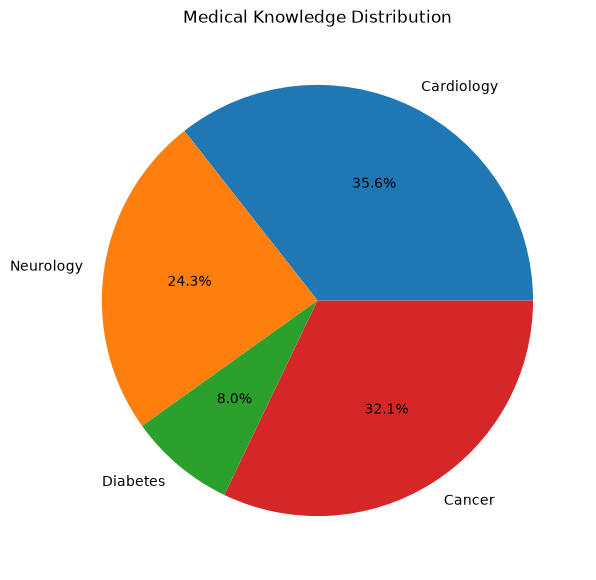

In [20]:
plt.figure(figsize=(7,7))

plt.pie(
    topic_df["Percentage"],
    labels=topic_df["Topic"],
    autopct="%1.1f%%"
)

plt.title("Medical Knowledge Distribution")

plt.show()

In [21]:
empty_pages = []

for doc in pdf_doc:

    if len(doc.page_content.strip()) == 0:

        empty_pages.append(doc.metadata["page"] + 1)

print(f"Total Empty Pages : {len(empty_pages)}")
print(empty_pages)

Total Empty Pages : 1
[1]


In [22]:
# Coverage tells us how much of the document actually contains extractable text

total_pages = len(pdf_doc)

pages_with_text = sum(
    len(doc.page_content.strip()) > 0
    for doc in pdf_doc
)

coverage = (pages_with_text / total_pages) * 100

print(f"OCR Coverage : {coverage:.2f}%")

OCR Coverage : 99.84%


In [23]:
# Some pages contain almost no extracted text

character_density = []

for doc in pdf_doc:

    character_density.append({

        "Page": doc.metadata["page"] + 1,

        "Characters": len(doc.page_content)

    })

character_density = pd.DataFrame(character_density)

character_density.head()


,Page,Characters
0,1,0
1,2,48
2,3,130
3,4,3820
4,5,675


In [25]:
# OCR often creates corrupted symbols

# Examples: ����, □□□, Ã, â€™,� 

# Too many such symbols indicate poor extraction quality

import re

ocr_errors = []

pattern = r"[�□]|Ã|â"

for doc in pdf_doc:

    errors = len(re.findall(pattern, doc.page_content))

    ocr_errors.append({

        "Page": doc.metadata["page"] + 1,

        "OCR Errors": errors

    })

ocr_errors = pd.DataFrame(ocr_errors)

ocr_errors.head()



,Page,OCR Errors
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
